In [134]:
# ═══════════════════════════════════════════════════════════════════════
# NOTEBOOK: NSD status inventory + COMIND subtype association
# Goal: determine whether Dan's file already contains non-NSD subjects,
#       and if so, test COMIND subtype x NSD status for association.
# ═══════════════════════════════════════════════════════════════════════
import re
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:.4f}".format)

# ── CONFIG ─────────────────────────────────────────────────────────────
# Point this at Dan's file. Either the shared path or your own upload.
DATA_PATH = (
    "/home/dsemchin/COMIND/experiments/"
    "2026_07_02_PPMI_K82_cold_gs_lowscalar_betaclin_betaall/"
    "PPMI_deviation_scores_with_beta_proba_per_timepoint.csv"
)

SUBJ_COL  = "subj_id"      # subject identifier
TIME_COL  = "time"         # within-subject visit ordering
STAGE_COL = "NSD_STAGE"    # NSD-ISS stage label as Dan shipped it

# The NSD-ISS values your current ordinal model keeps. Everything else
# is "off-ladder" and is what this notebook is hunting for.
ON_LADDER_VALUES = ["2", "2a", "2b", "3", "4", "5", "6"]

print("config loaded")

config loaded


In [135]:
if not Path(DATA_PATH).exists():
    raise FileNotFoundError(
        f"Not found: {DATA_PATH}\n"
        "Update DATA_PATH in Cell 1 to wherever you uploaded Dan's CSV."
    )

df_all = pd.read_csv(DATA_PATH)

print(f"loaded : {DATA_PATH}")
print(f"shape  : {df_all.shape[0]} rows x {df_all.shape[1]} columns")

for name, col in [("SUBJ_COL", SUBJ_COL),
                  ("TIME_COL", TIME_COL),
                  ("STAGE_COL", STAGE_COL)]:
    status = "OK" if col in df_all.columns else "*** MISSING ***"
    print(f"{name:<10} = {col!r:<15} {status}")

if SUBJ_COL in df_all.columns:
    print(f"\nsubjects: {df_all[SUBJ_COL].nunique()}")
    print(f"visits per subject: "
          f"min={df_all.groupby(SUBJ_COL).size().min()}, "
          f"max={df_all.groupby(SUBJ_COL).size().max()}, "
          f"median={df_all.groupby(SUBJ_COL).size().median():.0f}")

loaded : /home/dsemchin/COMIND/experiments/2026_07_02_PPMI_K82_cold_gs_lowscalar_betaclin_betaall/PPMI_deviation_scores_with_beta_proba_per_timepoint.csv
shape  : 839 rows x 351 columns
SUBJ_COL   = 'subj_id'       OK
TIME_COL   = 'time'          OK
STAGE_COL  = 'NSD_STAGE'     OK

subjects: 362
visits per subject: min=1, max=7, median=1


In [136]:
# Imaging columns are the wide block; everything else is worth eyeballing.
IMAGING_COLS = [c for c in df_all.columns if c.endswith("_resid")]

def _numsort(cols):
    return sorted(cols, key=lambda c: int(c.rsplit("_", 1)[-1]))

BASELINE_BETA_COLS = _numsort(
    [c for c in df_all.columns if re.fullmatch(r"beta_\d+", c)])
PROBA_COLS = _numsort(
    [c for c in df_all.columns if re.fullmatch(r"proba_\d+", c)])

NON_IMAGING_COLS = [c for c in df_all.columns if c not in set(IMAGING_COLS)]

print(f"imaging (_resid) columns : {len(IMAGING_COLS)}")
print(f"beta columns             : {BASELINE_BETA_COLS}")
print(f"proba columns            : {PROBA_COLS}")
print(f"\nall {len(NON_IMAGING_COLS)} non-imaging columns:")
print(NON_IMAGING_COLS)

# Does Dan already ship an SAA / NSD / cohort / diagnosis column?
KEYWORDS = ["saa", "nsd", "cohort", "diag", "status", "group",
            "patno", "enroll", "dat", "syn", "subtype", "label"]
hits = [c for c in df_all.columns
        if any(k in c.lower() for k in KEYWORDS)]
print(f"\ncandidate label/cohort columns ({len(hits)}):")
for c in hits:
    n_uniq = df_all[c].nunique(dropna=True)
    preview = df_all[c].dropna().unique()[:8]
    print(f"  {c:<30} unique={n_uniq:<6} e.g. {preview}")

imaging (_resid) columns : 84
beta columns             : ['beta_0', 'beta_1', 'beta_2', 'beta_3']
proba columns            : ['proba_0', 'proba_1', 'proba_2', 'proba_3']

all 267 non-imaging columns:
['index', 'L_bankssts', 'L_caudalanteriorcingulate', 'L_caudalmiddlefrontal', 'L_cuneus', 'L_entorhinal', 'L_fusiform', 'L_inferiorparietal', 'L_inferiortemporal', 'L_isthmuscingulate', 'L_lateraloccipital', 'L_lateralorbitofrontal', 'L_lingual', 'L_medialorbitofrontal', 'L_middletemporal', 'L_parahippocampal', 'L_paracentral', 'L_parsopercularis', 'L_parsorbitalis', 'L_parstriangularis', 'L_pericalcarine', 'L_postcentral', 'L_posteriorcingulate', 'L_precentral', 'L_precuneus', 'L_rostralanteriorcingulate', 'L_rostralmiddlefrontal', 'L_superiorfrontal', 'L_superiorparietal', 'L_superiortemporal', 'L_supramarginal', 'L_frontalpole', 'L_temporalpole', 'L_transversetemporal', 'L_insula', 'R_bankssts', 'R_caudalanteriorcingulate', 'R_caudalmiddlefrontal', 'R_cuneus', 'R_entorhinal', 'R_fusifor

In [137]:
if STAGE_COL not in df_all.columns:
    raise KeyError(f"{STAGE_COL!r} not in the file — check Cell 3 output.")

stage_raw = df_all[STAGE_COL].astype("string").str.strip().str.lower()
stage_raw = stage_raw.str.replace(r"\.0$", "", regex=True)

print("ROWS per raw NSD_STAGE value:")
print(stage_raw.value_counts(dropna=False).sort_index())

print("\nSUBJECTS per raw NSD_STAGE value:")
print(df_all.assign(_s=stage_raw)
            .groupby("_s", dropna=False)[SUBJ_COL]
            .nunique().sort_index())

print(f"\nrows with missing {STAGE_COL}: {stage_raw.isna().sum()}")

ROWS per raw NSD_STAGE value:
NSD_STAGE
2a           1
2b         123
3          503
4          127
5            8
6            1
not nsd     45
<NA>        31
Name: count, dtype: Int64

SUBJECTS per raw NSD_STAGE value:
_s
2a           1
2b          84
3          248
4           63
5            6
6            1
not nsd     24
<NA>        19
Name: subj_id, dtype: int64

rows with missing NSD_STAGE: 31


In [138]:
in_ladder = stage_raw.isin(ON_LADDER_VALUES)

on_df  = df_all.loc[in_ladder]
off_df = df_all.loc[~in_ladder]

print(f"ON-ladder  : {len(on_df):>5} rows  "
      f"{on_df[SUBJ_COL].nunique():>4} subjects")
print(f"OFF-ladder : {len(off_df):>5} rows  "
      f"{off_df[SUBJ_COL].nunique():>4} subjects")

print("\nOFF-ladder raw stage values:")
print(off_df[STAGE_COL].value_counts(dropna=False))

# The decisive question: did Dan's model produce betas/probas for them?
comind_cols = BASELINE_BETA_COLS + PROBA_COLS
if comind_cols and len(off_df):
    complete = ~off_df[comind_cols].isna().any(axis=1)
    print(f"\nOFF-ladder rows with COMPLETE betas + probas: "
          f"{int(complete.sum())} of {len(off_df)}")
    print(f"OFF-ladder subjects with >=1 complete row  : "
          f"{off_df.loc[complete, SUBJ_COL].nunique()}")
elif not len(off_df):
    print("\nNo off-ladder rows at all.")

ON-ladder  :   763 rows   319 subjects
OFF-ladder :    76 rows    43 subjects

OFF-ladder raw stage values:
NSD_STAGE
Not NSD    45
NaN        31
Name: count, dtype: int64

OFF-ladder rows with COMPLETE betas + probas: 62 of 76
OFF-ladder subjects with >=1 complete row  : 34


In [139]:
n_off_subj = off_df[SUBJ_COL].nunique() if len(off_df) else 0
n_off_complete = (
    off_df.loc[~off_df[comind_cols].isna().any(axis=1), SUBJ_COL].nunique()
    if (len(off_df) and comind_cols) else 0
)

print("=" * 66)
if n_off_complete >= 20:
    print(f"BRANCH A: {n_off_complete} off-ladder subjects have COMIND "
          f"features.\n  -> Item 4 is runnable. Next: merge PPMI NSD status "
          f"to split\n     'SAA-negative' from 'never tested', then build the "
          f"contingency table.")
elif n_off_subj > 0:
    print(f"BRANCH B: {n_off_subj} off-ladder subjects exist but only "
          f"{n_off_complete} have\n  COMIND features. Dan likely fit the model "
          f"on staged subjects only.\n  -> Ask Dan to score the rest with his "
          f"fitted model.")
else:
    print("BRANCH C: no off-ladder subjects in this file at all.\n"
          "  -> Dan filtered before export. You need a wider export from him\n"
          "     before item 4 is possible.")
print("=" * 66)

BRANCH A: 34 off-ladder subjects have COMIND features.
  -> Item 4 is runnable. Next: merge PPMI NSD status to split
     'SAA-negative' from 'never tested', then build the contingency table.


In [143]:
# ── Everything needed to know whether the test can run ────────────────
stage = (df_all[STAGE_COL].astype("string").str.strip().str.lower()
         .str.replace(r"\.0$", "", regex=True))

is_missing = stage.isna().to_numpy()
is_notnsd  = (stage == "not nsd").fillna(False).to_numpy()

df_all["_nsd"] = np.where(is_missing, "Unknown",
                  np.where(is_notnsd, "Not NSD", "NSD"))

subj = (df_all.groupby(SUBJ_COL)
              .agg(nsd=("_nsd", "first"), subtype=("subtype", "first"))
              .reset_index())

print(f"subjects: {len(subj)}")
print(f"missing subtype: {subj['subtype'].isna().sum()}\n")
print(pd.crosstab(subj["subtype"], subj["nsd"], dropna=False))

subjects: 362
missing subtype: 49

nsd      NSD  Not NSD  Unknown
subtype                       
1.0000    61        5        3
2.0000   104       12        5
3.0000    50        2        3
4.0000    64        2        2
NaN       40        3        6


In [144]:
# ── Is the missing subtype random, or structural? ─────────────────────
nv = df_all.groupby(SUBJ_COL).size().rename("n_visits")
chk = subj.join(nv, on=SUBJ_COL)
chk["has_subtype"] = chk["subtype"].notna()

print("visits per subject by subtype availability:")
print(chk.groupby("has_subtype")["n_visits"].describe()[["count", "mean", "50%", "max"]])

if "subgroup" in df_all.columns:
    sg = df_all.groupby(SUBJ_COL)["subgroup"].first()
    print("\nsubtype availability by genetic subgroup:")
    print(pd.crosstab(chk.join(sg, on=SUBJ_COL)["subgroup"], chk["has_subtype"]))

# ── Do the betas explain it? ──────────────────────────────────────────
bmiss = (df_all.groupby(SUBJ_COL)[BASELINE_BETA_COLS]
               .apply(lambda g: g.isna().all().all()).rename("betas_all_missing"))
print("\nsubtype missing vs betas missing:")
print(pd.crosstab(chk.join(bmiss, on=SUBJ_COL)["betas_all_missing"],
                  chk["has_subtype"]))

visits per subject by subtype availability:
               count   mean    50%    max
has_subtype                              
False        49.0000 2.3469 1.0000 7.0000
True        313.0000 2.3131 1.0000 7.0000

subtype availability by genetic subgroup:
has_subtype  False  True 
subgroup                 
GBA              0     12
LRRK2            1      5
LRRK2 + GBA      0      1
PRKN             1      8
Sporadic PD     41    287

subtype missing vs betas missing:
has_subtype        False  True 
betas_all_missing              
False                  0    313
True                  49      0


In [146]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 8 — Contingency table + association tests
#   rows = Dan's subject-level COMIND subtype
#   cols = NSD status (NSD vs Not NSD); "Unknown" excluded
# ═══════════════════════════════════════════════════════════════════════
from scipy.stats import chi2_contingency

SUBTYPE_COL = "subtype"        # subject-level label (constant within subject)

# ── Subject-level table ───────────────────────────────────────────────
stage = (df_all[STAGE_COL].astype("string").str.strip().str.lower()
         .str.replace(r"\.0$", "", regex=True))
is_missing = stage.isna().to_numpy()
is_notnsd  = (stage == "not nsd").fillna(False).to_numpy()
df_all["_nsd"] = np.where(is_missing, "Unknown",
                  np.where(is_notnsd, "Not NSD", "NSD"))

subj_df = (df_all.sort_values([SUBJ_COL, TIME_COL])
                 .groupby(SUBJ_COL)
                 .agg(nsd_status=("_nsd", "first"),
                      subtype=(SUBTYPE_COL, "first"))
                 .reset_index())

ana = subj_df[subj_df["nsd_status"].isin(["NSD", "Not NSD"])
              & subj_df["subtype"].notna()].copy()
ana["subtype"] = ana["subtype"].astype(int).map(lambda k: f"Subtype {k}")

tab = pd.crosstab(ana["subtype"], ana["nsd_status"])[["NSD", "Not NSD"]]

print("OBSERVED (subjects)")
print(tab)
print(f"\nanalysed : {len(ana)} subjects")
print(f"excluded : {len(subj_df) - len(ana)} "
      f"(unknown NSD status or not scored by COMIND)")

print("\nCOLUMN % — subtype composition within each NSD group")
print((tab / tab.sum(axis=0) * 100).round(1))
print("\nROW % — % Not NSD within each subtype")
print((tab["Not NSD"] / tab.sum(axis=1) * 100).round(1))

# ── Chi-squared ───────────────────────────────────────────────────────
chi2, p_chi2, dof, exp = chi2_contingency(tab)
n = int(tab.values.sum())
cramers_v = np.sqrt(chi2 / (n * (min(tab.shape) - 1)))

print("\nEXPECTED counts under independence")
print(pd.DataFrame(exp, index=tab.index, columns=tab.columns).round(2))
n_small = int((exp < 5).sum())
print(f"cells with expected < 5 : {n_small} of {exp.size}"
      + ("   <-- asymptotic p is UNRELIABLE" if n_small else ""))

print(f"\nchi2 = {chi2:.4f}   dof = {dof}   asymptotic p = {p_chi2:.4g}")
print(f"Cramer's V = {cramers_v:.4f}   (0.1 small / 0.3 medium / 0.5 large)")

# ── Monte Carlo permutation test (valid with sparse cells) ────────────
rng     = np.random.default_rng(10)
codes   = pd.Categorical(ana["subtype"]).codes
row_tot = np.bincount(codes, minlength=codes.max() + 1).astype(float)
is_neg  = (ana["nsd_status"].to_numpy() == "Not NSD").astype(float)
col_tot = np.array([n - is_neg.sum(), is_neg.sum()])
exp_fix = np.outer(row_tot, col_tot) / n

def _chi2_fast(neg_counts):
    obs = np.column_stack([row_tot - neg_counts, neg_counts])
    with np.errstate(divide="ignore", invalid="ignore"):
        t = (obs - exp_fix) ** 2 / exp_fix
    return np.nansum(np.where(np.isfinite(t), t, 0.0))

B = 20000
null = np.array([
    _chi2_fast(np.bincount(codes, weights=rng.permutation(is_neg),
                           minlength=len(row_tot)))
    for _ in range(B)])
p_perm = (np.sum(null >= chi2) + 1) / (B + 1)
print(f"\nPERMUTATION p ({B:,} shuffles) = {p_perm:.4g}")

# ── Which cells drive it ──────────────────────────────────────────────
adj = ((tab.values - exp)
       / np.sqrt(exp
                 * (1 - tab.sum(axis=1).values[:, None] / n)
                 * (1 - tab.sum(axis=0).values[None, :] / n)))
print("\nADJUSTED RESIDUALS   (|z| > 2 = over/under-represented)")
print(pd.DataFrame(adj, index=tab.index, columns=tab.columns).round(2))

OBSERVED (subjects)
nsd_status  NSD  Not NSD
subtype                 
Subtype 1    61        5
Subtype 2   104       12
Subtype 3    50        2
Subtype 4    64        2

analysed : 300 subjects
excluded : 62 (unknown NSD status or not scored by COMIND)

COLUMN % — subtype composition within each NSD group
nsd_status     NSD  Not NSD
subtype                    
Subtype 1  21.9000  23.8000
Subtype 2  37.3000  57.1000
Subtype 3  17.9000   9.5000
Subtype 4  22.9000   9.5000

ROW % — % Not NSD within each subtype
subtype
Subtype 1    7.6000
Subtype 2   10.3000
Subtype 3    3.8000
Subtype 4    3.0000
dtype: float64

EXPECTED counts under independence
nsd_status      NSD  Not NSD
subtype                     
Subtype 1   61.3800   4.6200
Subtype 2  107.8800   8.1200
Subtype 3   48.3600   3.6400
Subtype 4   61.3800   4.6200
cells with expected < 5 : 3 of 8   <-- asymptotic p is UNRELIABLE

chi2 = 4.4193   dof = 3   asymptotic p = 0.2196
Cramer's V = 0.1214   (0.1 small / 0.3 medium / 0.5 large

In [148]:
# ═══════════════════════════════════════════════════════════════════════
# Binary NSD vs Not NSD classifier (subject-level pilot)
# ═══════════════════════════════════════════════════════════════════════
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

CLINICAL_COLS  = [c for c in ["MCATOT", "TD_score", "PIGD_score"]
                  if c in df_all.columns]
PROBA_FEATURES = [c for c in PROBA_COLS if c != "proba_0"]   # sum-to-1 redundancy

# ── One row per subject: TRUE baseline visit (no cross-visit mixing) ──
base = (df_all.sort_values([SUBJ_COL, TIME_COL])
              .drop_duplicates(subset=[SUBJ_COL], keep="first")
              .reset_index(drop=True))

base["y"] = (base["_nsd"] == "Not NSD").astype(int)

# subgroup has missing values then keep them as NaN, not a silent 0
sg     = base["subgroup"].astype("string").str.strip().str.lower()
is_gen = (sg != "sporadic pd").fillna(False).to_numpy().astype(float)
base["is_genetic"] = np.where(sg.isna().to_numpy(), np.nan, is_gen)

base = base[base["_nsd"].isin(["NSD", "Not NSD"])].copy()

print(f"subjects with known NSD status: {len(base)}   "
      f"negatives: {int(base['y'].sum())}")
print(f"baseline time values: "
      f"{base[TIME_COL].value_counts().sort_index().to_dict()}")
print(f"subgroup missing (genetics arm will drop these): "
      f"{int(base['is_genetic'].isna().sum())}\n")

ABLATIONS = {
    "genetics only":              ["is_genetic"],
    "clinical only":              CLINICAL_COLS,
    "betas only":                 BASELINE_BETA_COLS,
    "subtype probabilities only": PROBA_FEATURES,
    "clinical + betas + probas":  CLINICAL_COLS + BASELINE_BETA_COLS + PROBA_FEATURES,
    "imaging only  [EXPLORATORY]": IMAGING_COLS,
    "everything    [EXPLORATORY]": (CLINICAL_COLS + BASELINE_BETA_COLS
                                    + PROBA_FEATURES + IMAGING_COLS),
}

# ── Cohort size per block: complete-case is applied PER ABLATION ──────
print(f"{'ablation':<30}{'n':>6}{'neg':>6}{'feats':>7}{'EPV':>7}")
print("-" * 56)
for name, cols in ABLATIONS.items():
    sub = base.dropna(subset=cols)
    neg = int(sub["y"].sum())
    print(f"{name:<30}{len(sub):>6}{neg:>6}{len(cols):>7}{neg/len(cols):>7.1f}")

# ── Cross-validated AUC + permutation p-value ─────────────────────────
def cv_auc(X, y, seed=10, n_rep=5):
    pipe = make_pipeline(
        StandardScaler(),
        LogisticRegression(penalty="l2", C=0.1, class_weight="balanced",
                           max_iter=5000, solver="lbfgs"))
    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=n_rep, random_state=seed)
    return cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc").mean()

N_PERM = 200
rng = np.random.default_rng(10)
rows = []

for name, cols in ABLATIONS.items():
    sub = base.dropna(subset=cols)
    X, y = sub[cols].to_numpy(float), sub["y"].to_numpy()
    if y.sum() < 5:
        continue
    obs  = cv_auc(X, y)
    null = np.array([cv_auc(X, rng.permutation(y), seed=1000 + i, n_rep=1)
                     for i in range(N_PERM)])
    rows.append({"ablation": name, "n": len(sub), "neg": int(y.sum()),
                 "n_feat": len(cols), "cv_auc": obs,
                 "null_mean": null.mean(),
                 "perm_p": (np.sum(null >= obs) + 1) / (N_PERM + 1)})

res = pd.DataFrame(rows).sort_values("cv_auc", ascending=False)
print("\n" + "=" * 68)
print(res.to_string(index=False))
print("=" * 68)
print(f"detection floor at n_neg={int(base['y'].sum())}: AUC ~0.72")

subjects with known NSD status: 343   negatives: 24
baseline time values: {0: 340, 12: 3}
subgroup missing (genetics arm will drop these): 0

ablation                           n   neg  feats    EPV
--------------------------------------------------------
genetics only                    343    24      1   24.0
clinical only                    343    24      3    8.0
betas only                       300    21      4    5.2
subtype probabilities only       300    21      3    7.0
clinical + betas + probas        300    21     10    2.1
imaging only  [EXPLORATORY]      338    24     84    0.3
everything    [EXPLORATORY]      300    21     94    0.2

                   ablation   n  neg  n_feat  cv_auc  null_mean  perm_p
everything    [EXPLORATORY] 300   21      94  0.7103     0.5060  0.0149
imaging only  [EXPLORATORY] 338   24      84  0.6888     0.5069  0.0249
  clinical + betas + probas 300   21      10  0.6493     0.5092  0.0547
              clinical only 343   24       3  0.5785    

In [149]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 11 — Negative-retention diagnostics
# ═══════════════════════════════════════════════════════════════════════
known = df_all[df_all["_nsd"].isin(["NSD", "Not NSD"])].copy()
known["y"] = (known["_nsd"] == "Not NSD").astype(int)
known["is_genetic"] = (known["subgroup"].astype("string").str.strip()
                            .str.lower() != "sporadic pd").astype(int)

N_NEG = known.loc[known["y"] == 1, SUBJ_COL].nunique()
print(f"CEILING — negatives with known NSD status: {N_NEG}\n")

BLOCKS = {"genetics": ["is_genetic"], "clinical": CLINICAL_COLS,
          "betas": BASELINE_BETA_COLS, "probas": PROBA_FEATURES,
          "imaging": IMAGING_COLS}

neg = known[known["y"] == 1]
base_first = neg.sort_values([SUBJ_COL, TIME_COL]).groupby(SUBJ_COL).first()

print(f"{'block':<10}{'complete@BL':>13}{'complete@ANY':>14}{'never':>8}{'recover':>9}")
print("-" * 54)
for name, cols in BLOCKS.items():
    at_bl  = int(base_first[cols].notna().all(axis=1).sum())
    at_any = int(neg.groupby(SUBJ_COL)
                    .apply(lambda g: g[cols].notna().all(axis=1).any()).sum())
    print(f"{name:<10}{at_bl:>13}{at_any:>14}{N_NEG - at_any:>8}{at_any - at_bl:>9}")

# ── Which individual columns are NaN for negatives? ──────────────────
all_cols = [c for cs in BLOCKS.values() for c in cs]
nan_by_col = base_first[all_cols].isna().sum()
culprits = nan_by_col[nan_by_col > 0].sort_values(ascending=False)
print(f"\ncolumns with ANY NaN among the {N_NEG} negatives at baseline: "
      f"{len(culprits)}")
print(culprits.head(15).to_string() if len(culprits) else "  (none)")

CEILING — negatives with known NSD status: 24

block       complete@BL  complete@ANY   never  recover
------------------------------------------------------
genetics             24            24       0        0
clinical             24            24       0        0
betas                21            21       3        0
probas               21            21       3        0
imaging              24            24       0        0

columns with ANY NaN among the 24 negatives at baseline: 7
beta_0     3
beta_1     3
beta_2     3
beta_3     3
proba_1    3
proba_2    3
proba_3    3


/tmp/ipykernel_22582/4242970769.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  at_any = int(neg.groupby(SUBJ_COL)
/tmp/ipykernel_22582/4242970769.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  at_any = int(neg.groupby(SUBJ_COL)
/tmp/ipykernel_22582/4242970769.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version o

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# Binary NSD vs Not NSD classifier (subject-level pilot)
#   Elastic-net logistic regression, NESTED CV:
#     inner loop  -> selects (C, l1_ratio)
#     outer loop  -> estimates AUC on folds the inner loop never saw
#   Fixed-C ridge is reported alongside as a stability check.
# ═══════════════════════════════════════════════════════════════════════
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (RepeatedStratifiedKFold, StratifiedKFold,
                                     cross_val_score, GridSearchCV)
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

CLINICAL_COLS  = [c for c in ["MCATOT", "TD_score", "PIGD_score"]
                  if c in df_all.columns]
PROBA_FEATURES = [c for c in PROBA_COLS if c != "proba_0"]   # sum-to-1 redundancy

# ── One row per subject: TRUE baseline visit (no cross-visit mixing) ──
base = (df_all.sort_values([SUBJ_COL, TIME_COL])
              .drop_duplicates(subset=[SUBJ_COL], keep="first")
              .reset_index(drop=True))

base["y"] = (base["_nsd"] == "Not NSD").astype(int)

# subgroup has missing values -> keep them as NaN, not a silent 0
sg     = base["subgroup"].astype("string").str.strip().str.lower()
is_gen = (sg != "sporadic pd").fillna(False).to_numpy().astype(float)
base["is_genetic"] = np.where(sg.isna().to_numpy(), np.nan, is_gen)

base = base[base["_nsd"].isin(["NSD", "Not NSD"])].copy()

print(f"subjects with known NSD status: {len(base)}   "
      f"negatives: {int(base['y'].sum())}")
print(f"baseline time values: "
      f"{base[TIME_COL].value_counts().sort_index().to_dict()}")
print(f"subgroup missing (genetics arm will drop these): "
      f"{int(base['is_genetic'].isna().sum())}\n")

ABLATIONS = {
    "genetics only":               ["is_genetic"],
    "clinical only":               CLINICAL_COLS,
    "betas only":                  BASELINE_BETA_COLS,
    "subtype probabilities only":  PROBA_FEATURES,
    "clinical + betas + probas":   CLINICAL_COLS + BASELINE_BETA_COLS + PROBA_FEATURES,
    "imaging only  [EXPLORATORY]": IMAGING_COLS,
    "everything    [EXPLORATORY]": (CLINICAL_COLS + BASELINE_BETA_COLS
                                    + PROBA_FEATURES + IMAGING_COLS),
}

# ── Cohort size per block: complete-case is applied PER ABLATION ──────
print(f"{'ablation':<30}{'n':>6}{'neg':>6}{'feats':>7}{'EPV':>7}")
print("-" * 56)
for name, cols in ABLATIONS.items():
    sub = base.dropna(subset=cols)
    neg = int(sub["y"].sum())
    print(f"{name:<30}{len(sub):>6}{neg:>6}{len(cols):>7}{neg/len(cols):>7.1f}")

# ═══ MODELS ════════════════════════════════════════════════════════════
PARAM_GRID = {
    "logisticregression__C":        [0.003, 0.01, 0.03, 0.1, 0.3, 1.0],
    "logisticregression__l1_ratio": [0.0, 0.5, 1.0],   # 0=ridge 1=lasso
}

def make_search(seed=10, inner_splits=3):
    """Elastic net + inner grid search. saga REQUIRES scaled input."""
    pipe = make_pipeline(
        StandardScaler(),
        LogisticRegression(penalty="elasticnet", solver="saga",
                           class_weight="balanced", max_iter=20000,
                           tol=1e-3, random_state=0))
    inner = StratifiedKFold(n_splits=inner_splits, shuffle=True,
                            random_state=seed)
    return GridSearchCV(pipe, PARAM_GRID, scoring="roc_auc",
                        cv=inner, n_jobs=-1, refit=True)

def cv_auc_nested(X, y, seed=10, n_rep=5):
    """Outer folds never inform hyperparameter choice -> unbiased estimate."""
    outer = RepeatedStratifiedKFold(n_splits=5, n_repeats=n_rep,
                                    random_state=seed)
    return cross_val_score(make_search(seed), X, y, cv=outer,
                           scoring="roc_auc", n_jobs=-1).mean()

def cv_auc_fixed(X, y, seed=10, n_rep=5):
    """Original fixed-C ridge, kept as a stability comparison."""
    pipe = make_pipeline(
        StandardScaler(),
        LogisticRegression(penalty="l2", C=0.1, class_weight="balanced",
                           max_iter=5000, solver="lbfgs"))
    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=n_rep,
                                 random_state=seed)
    return cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc").mean()

# ═══ RUN ═══════════════════════════════════════════════════════════════
# Permutations are expensive under nesting.
REPORT = {"imaging only  [EXPLORATORY]", "everything    [EXPLORATORY]",
          "clinical + betas + probas", "clinical only"}
N_PERM = 100
rng, rows = np.random.default_rng(10), []

for name, cols in ABLATIONS.items():
    sub  = base.dropna(subset=cols)
    X, y = sub[cols].to_numpy(float), sub["y"].to_numpy()
    if y.sum() < 5:
        continue
    print(f"  running {name} ...", flush=True)

    obs_nested = cv_auc_nested(X, y)
    obs_fixed  = cv_auc_fixed(X, y)

    if name in REPORT:
        null = np.array([cv_auc_nested(X, rng.permutation(y),
                                       seed=1000 + i, n_rep=1)
                         for i in range(N_PERM)])
        nm, pp = null.mean(), (np.sum(null >= obs_nested) + 1) / (N_PERM + 1)
    else:
        nm = pp = np.nan

    rows.append({"ablation": name, "n": len(sub), "neg": int(y.sum()),
                 "n_feat": len(cols),
                 "auc_nested": round(obs_nested, 4),
                 "auc_fixedC": round(obs_fixed, 4),
                 "null_mean": round(nm, 4) if nm == nm else None,
                 "perm_p":    round(pp, 4) if pp == pp else None})

res = pd.DataFrame(rows).sort_values("auc_nested", ascending=False)
print("\n" + "=" * 84)
print(res.to_string(index=False))
print("=" * 84)
print(f"detection floor at n_neg={int(base['y'].sum())}: AUC ~0.72")

# ── Which hyperparameters does the inner loop actually pick? ──────────
def selected_params(cols, seed=10, n_rep=2):
    sub  = base.dropna(subset=cols)
    X, y = sub[cols].to_numpy(float), sub["y"].to_numpy()
    outer = RepeatedStratifiedKFold(n_splits=5, n_repeats=n_rep,
                                    random_state=seed)
    picks = []
    for tr, _ in outer.split(X, y):
        s = make_search(seed); s.fit(X[tr], y[tr])
        picks.append((s.best_params_["logisticregression__C"],
                      s.best_params_["logisticregression__l1_ratio"]))
    return pd.Series(picks, dtype=object).value_counts()

print("\n(C, l1_ratio) selected across outer folds — imaging only:")
print(selected_params(IMAGING_COLS))

subjects with known NSD status: 343   negatives: 24
baseline time values: {0: 340, 12: 3}
subgroup missing (genetics arm will drop these): 0

ablation                           n   neg  feats    EPV
--------------------------------------------------------
genetics only                    343    24      1   24.0
clinical only                    343    24      3    8.0
betas only                       300    21      4    5.2
subtype probabilities only       300    21      3    7.0
clinical + betas + probas        300    21     10    2.1
imaging only  [EXPLORATORY]      338    24     84    0.3
everything    [EXPLORATORY]      300    21     94    0.2
  running genetics only ...
  running clinical only ...


/home/aantar2/miniconda3/envs/alan_python_3_9/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/aantar2/miniconda3/envs/alan_python_3_9/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/aantar2/miniconda3/envs/alan_python_3_9/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/aantar2/miniconda3/envs/alan_python_3_9/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/aantar2/miniconda3/envs/alan_python_3_9/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means

  running betas only ...


/home/aantar2/miniconda3/envs/alan_python_3_9/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/aantar2/miniconda3/envs/alan_python_3_9/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/aantar2/miniconda3/envs/alan_python_3_9/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


  running subtype probabilities only ...


...

  running imaging only  [EXPLORATORY] ...


/home/aantar2/miniconda3/envs/alan_python_3_9/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/aantar2/miniconda3/envs/alan_python_3_9/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/aantar2/miniconda3/envs/alan_python_3_9/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/aantar2/miniconda3/envs/alan_python_3_9/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/aantar2/miniconda3/envs/alan_python_3_9/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means

  running everything    [EXPLORATORY] ...


/home/aantar2/miniconda3/envs/alan_python_3_9/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/aantar2/miniconda3/envs/alan_python_3_9/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/aantar2/miniconda3/envs/alan_python_3_9/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/aantar2/miniconda3/envs/alan_python_3_9/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/aantar2/miniconda3/envs/alan_python_3_9/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means


                   ablation   n  neg  n_feat  auc_nested  auc_fixedC  null_mean  perm_p
everything    [EXPLORATORY] 300   21      94      0.7192      0.7103     0.4950  0.0099
imaging only  [EXPLORATORY] 338   24      84      0.7150      0.6888     0.5031  0.0099
  clinical + betas + probas 300   21      10      0.6368      0.6493     0.4924  0.0693
 subtype probabilities only 300   21       3      0.5794      0.5780        NaN     NaN
              clinical only 343   24       3      0.5645      0.5785     0.5022  0.1881
              genetics only 343   24       1      0.5022      0.4868        NaN     NaN
                 betas only 300   21       4      0.4824      0.4974        NaN     NaN
detection floor at n_neg=24: AUC ~0.72

(C, l1_ratio) selected across outer folds — imaging only:
(0.03, 1.0)    4
(0.03, 0.5)    4
(0.1, 0.5)     1
(0.1, 1.0)     1
Name: count, dtype: int64


/home/aantar2/miniconda3/envs/alan_python_3_9/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/aantar2/miniconda3/envs/alan_python_3_9/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/aantar2/miniconda3/envs/alan_python_3_9/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/aantar2/miniconda3/envs/alan_python_3_9/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/aantar2/miniconda3/envs/alan_python_3_9/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means

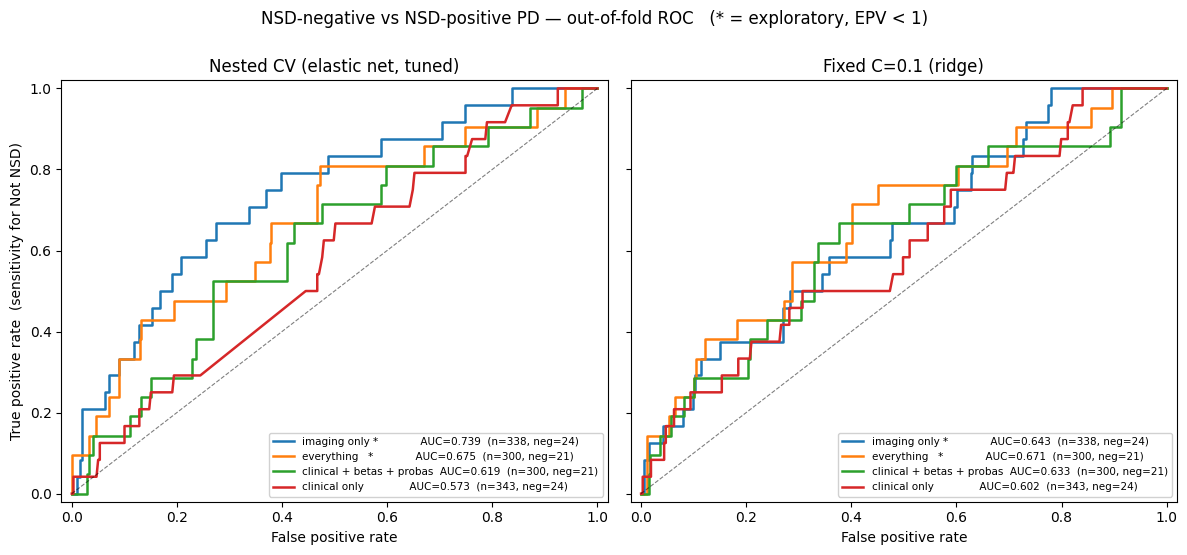

In [157]:
# ═══════════════════════════════════════════════════════════════════════
# ROC curves from OUT-OF-FOLD predictions (nested vs fixed-C)
#   Curves are pooled across folds of ONE repeat, so every subject
#   contributes exactly one held-out prediction.
# ═══════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.base import clone

def oof_scores(estimator, X, y, seed=10):
    """Held-out predicted probability for every subject, one repeat."""
    oof = np.full(len(y), np.nan)
    cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    for tr, te in cv.split(X, y):
        m = clone(estimator).fit(X[tr], y[tr])
        oof[te] = m.predict_proba(X[te])[:, 1]
    return oof

def fixed_pipe():
    return make_pipeline(
        StandardScaler(),
        LogisticRegression(penalty="l2", C=0.1, class_weight="balanced",
                           max_iter=5000, solver="lbfgs"))

PLOT_ARMS = ["imaging only  [EXPLORATORY]", "everything    [EXPLORATORY]",
             "clinical + betas + probas", "clinical only"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharey=True)

for ax, (label, make_est) in zip(
        axes, [("Nested CV (elastic net, tuned)", lambda: make_search(10)),
               ("Fixed C=0.1 (ridge)",            fixed_pipe)]):
    for name in PLOT_ARMS:
        cols = ABLATIONS[name]
        sub  = base.dropna(subset=cols)
        X, y = sub[cols].to_numpy(float), sub["y"].to_numpy()

        oof = oof_scores(make_est(), X, y)
        fpr, tpr, _ = roc_curve(y, oof)
        auc = roc_auc_score(y, oof)
        ax.plot(fpr, tpr, lw=1.8,
                label=f"{name.replace('  [EXPLORATORY]',' *'):<26} "
                      f"AUC={auc:.3f}  (n={len(y)}, neg={int(y.sum())})")

    ax.plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.5)
    ax.set_xlabel("False positive rate")
    ax.set_title(label)
    ax.legend(loc="lower right", fontsize=7.5, framealpha=0.9)
    ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)

axes[0].set_ylabel("True positive rate  (sensitivity for Not NSD)")
fig.suptitle("NSD-negative vs NSD-positive PD — out-of-fold ROC   "
             "(* = exploratory, EPV < 1)", y=1.00)
plt.tight_layout()
plt.show()

In [159]:
# ═══════════════════════════════════════════════════════════════════════
# Permutation tests for the negative-control arms, kept in a table
# ═══════════════════════════════════════════════════════════════════════
N_PERM_NC = 100
rng_nc = np.random.default_rng(20)
nc_rows = []

for name in ["betas only", "genetics only", "subtype probabilities only"]:
    cols = ABLATIONS[name]
    sub  = base.dropna(subset=cols)
    X, y = sub[cols].to_numpy(float), sub["y"].to_numpy()

    obs  = cv_auc_nested(X, y)
    null = np.array([cv_auc_nested(X, rng_nc.permutation(y),
                                   seed=2000 + i, n_rep=1)
                     for i in range(N_PERM_NC)])
    p = (np.sum(null >= obs) + 1) / (N_PERM_NC + 1)

    nc_rows.append({"ablation": name,
                    "null_mean_nc": round(null.mean(), 4),
                    "perm_p_nc":    round(p, 4)})
    print(f"{name:<28} auc={obs:.4f}  null={null.mean():.4f}  p={p:.4f}",
          flush=True)

nc = pd.DataFrame(nc_rows)

# ── Merge into the main results table ────────────────────────────────
full = res.merge(nc, on="ablation", how="left")
full["null_mean"] = full["null_mean"].fillna(full.pop("null_mean_nc"))
full["perm_p"]    = full["perm_p"].fillna(full.pop("perm_p_nc"))

full = full.sort_values("auc_nested", ascending=False)
print("\n" + "=" * 88)
print(full.to_string(index=False))
print("=" * 88)

full.to_csv("nsd_binary_ablation_results.csv", index=False)
print("\nsaved -> nsd_binary_ablation_results.csv")

/home/aantar2/miniconda3/envs/alan_python_3_9/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/aantar2/miniconda3/envs/alan_python_3_9/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/aantar2/miniconda3/envs/alan_python_3_9/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/aantar2/miniconda3/envs/alan_python_3_9/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/aantar2/miniconda3/envs/alan_python_3_9/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means

betas only                   auc=0.4824  null=0.4920  p=0.5644
genetics only                auc=0.5022  null=0.4974  p=0.4455


/home/aantar2/miniconda3/envs/alan_python_3_9/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/aantar2/miniconda3/envs/alan_python_3_9/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/aantar2/miniconda3/envs/alan_python_3_9/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/aantar2/miniconda3/envs/alan_python_3_9/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/aantar2/miniconda3/envs/alan_python_3_9/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means

subtype probabilities only   auc=0.5794  null=0.4967  p=0.1188

                   ablation   n  neg  n_feat  auc_nested  auc_fixedC  null_mean  perm_p
everything    [EXPLORATORY] 300   21      94      0.7192      0.7103     0.4950  0.0099
imaging only  [EXPLORATORY] 338   24      84      0.7150      0.6888     0.5031  0.0099
  clinical + betas + probas 300   21      10      0.6368      0.6493     0.4924  0.0693
 subtype probabilities only 300   21       3      0.5794      0.5780     0.4967  0.1188
              clinical only 343   24       3      0.5645      0.5785     0.5022  0.1881
              genetics only 343   24       1      0.5022      0.4868     0.4974  0.4455
                 betas only 300   21       4      0.4824      0.4974     0.4920  0.5644

saved -> nsd_binary_ablation_results.csv
